# Atividade 09 - UMAP Vinicius Cordeiro

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.neighbors import NearestNeighbors

# Configurações de plotagem
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# Gerar o dataset Swiss Roll
n_samples = 1500
noise = 0.05
X, color = make_swiss_roll(n_samples, noise=noise, random_state=42)

# Normalizar os dados
X = (X - np.min(X)) / (np.max(X) - np.min(X))

In [4]:
class UMAP:
    def __init__(self, n_neighbors=15, n_components=2, n_epochs=200, lr=0.5, random_state=None): #epocas eh a iterações
        self.n_neighbors = n_neighbors
        self.n_components = n_components
        self.n_epochs = n_epochs
        self.lr = lr
        self.random_state = np.random.RandomState(random_state)
        self.a, self.b = 1.929, 0.7915  # parâmetros da função de afinidade do UMAP

    def _find_sigma(self, distances, rho):
        """Busca binária para encontrar sigma."""
        target = np.log2(self.n_neighbors)
        low, high = 1e-3, 10.0
        for _ in range(30):
            mid = (low + high) / 2
            psum = np.sum(np.exp(-(np.maximum(0, distances - rho)) / mid))
            if abs(psum - target) < 1e-5:
                return mid
            if psum > target:
                high = mid
            else:
                low = mid
        return mid

    def _build_neighbor_graph(self, X):
        """Etapa 1: constrói o grafo de vizinhança baseado em distâncias."""
        n = X.shape[0]

        # Encontra os k vizinhos mais próximos de cada ponto
        knn = NearestNeighbors(n_neighbors=self.n_neighbors).fit(X)
        dists, inds = knn.kneighbors(X)

        # Calcular rho e sigma
        # rho_i: distância mínima não nula (define o raio local de cada ponto)
        # sigma_i: largura da distribuição local (ajustada por busca binária)
        rho = dists[:, 1]     #offset e a distancia do prox ponto mais proximo
        sigma = np.zeros(n)   #"desvio padrao" "largura"
        for i in range(n):
            sigma[i] = self._find_sigma(dists[i, 1:], rho[i])

        # Cria pares (i, j) para todas as conexões entre ponto i e seus vizinhos j
        rows = np.repeat(np.arange(n), self.n_neighbors)
        cols = inds.flatten()

        # Calcula distâncias entre cada ponto e seus vizinhos correspondentes
        dist = np.linalg.norm(X[rows] - X[cols], axis=1)

        # Subtrai o raio local rho_i e zera valores negativos
        dist = np.maximum(0, dist - rho[rows])  #eh aqui onde entra o offset

        # Converte distâncias em probabilidades (função de afinidade exponencial)
        p = np.exp(-dist / (sigma[rows] + 1e-8))

        # União fuzzy (p_ij + p_ji - p_ij*p_ji)
        p_matrix = np.zeros((n, n))
        p_matrix[rows, cols] = p
        p = p_matrix + p_matrix.T - p_matrix * p_matrix.T

        # Extrai apenas pares conectados e normaliza os pesos finais
        rows, cols = np.where(p > 0)
        p = p[rows, cols]
        p /= (p.max() + 1e-8)
        return rows, cols, p

    def _optimize_embedding(self, rows, cols, weights, Y):
        """Etapa 2: otimiza as posições no espaço reduzido."""
        eps = 1e-8
        for _ in range(self.n_epochs):
            # Atração entre vizinhos reais
            i = self.random_state.randint(0, len(weights), len(Y))
            j = cols[i]
            diff = Y[rows[i]] - Y[j]
            dist2 = np.sum(diff**2, axis=1)
            grad = (2 * self.a * self.b * (dist2 + eps)**(self.b - 1) /
                    (1 + self.a * (dist2 + eps)**self.b))[:, None] * diff
            Y[rows[i]] -= self.lr * grad
            Y[j] += self.lr * grad

            # Repulsão entre pares aleatórios
            neg_i = self.random_state.randint(0, len(Y), len(Y))
            neg_j = self.random_state.randint(0, len(Y), len(Y))
            diff = Y[neg_i] - Y[neg_j]
            dist2 = np.sum(diff**2, axis=1)
            grad = (-self.b / (1 + self.a * (dist2 + eps)**self.b))[:, None] * diff
            Y[neg_i] -= self.lr * grad

        return Y

    def fit_transform(self, X):
        """Executa o UMAP simplificado."""
        rows, cols, weights = self._build_neighbor_graph(X) #fzr o grafico de vizinhos
        Y = self.random_state.normal(scale=0.01, size=(X.shape[0], self.n_components))
        return self._optimize_embedding(rows, cols, weights, Y)

### Exercício 1

Treine diferentes UMAPs com diferentes valores de pontos vizinhos, para o dataset sintético e plote cada um deles.

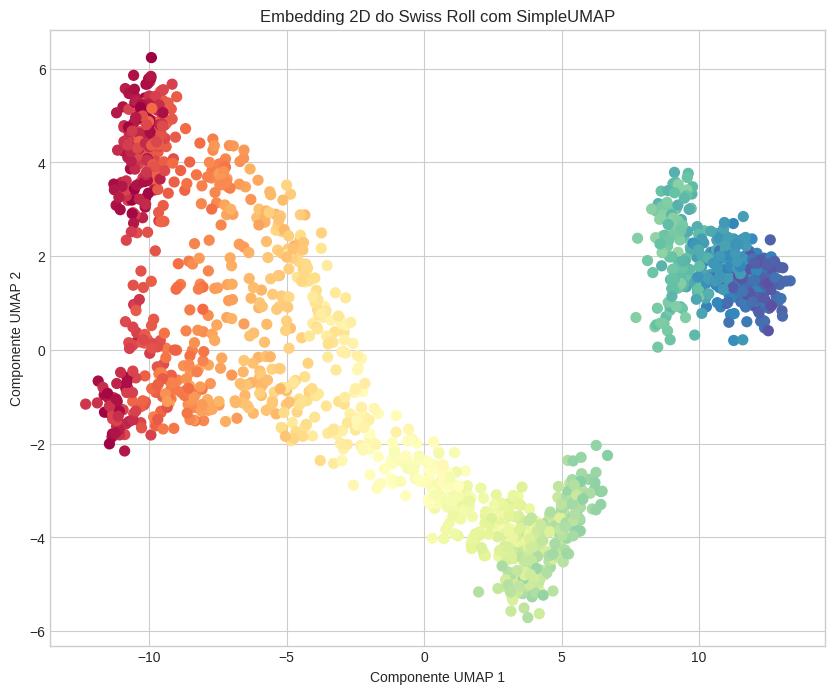

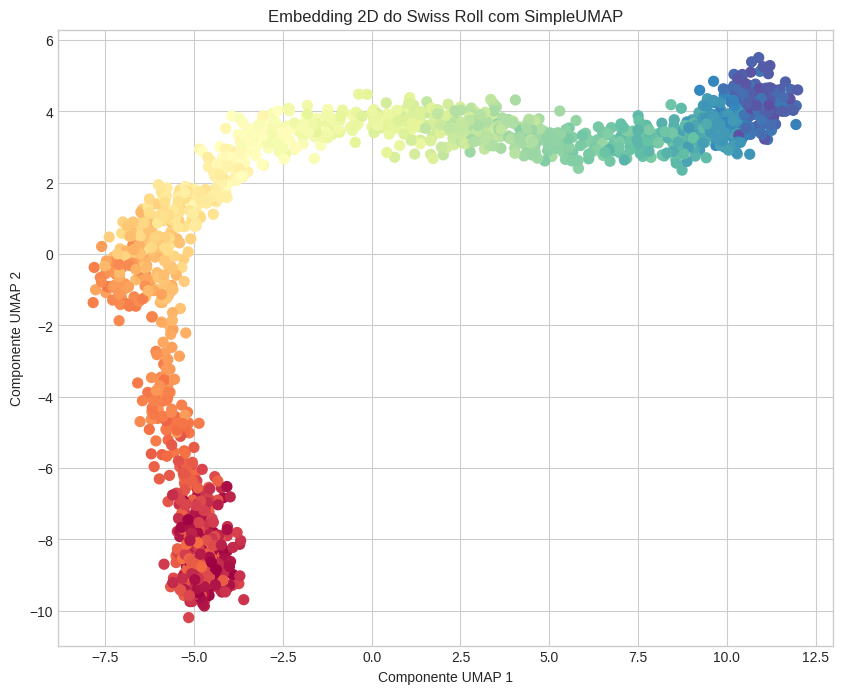

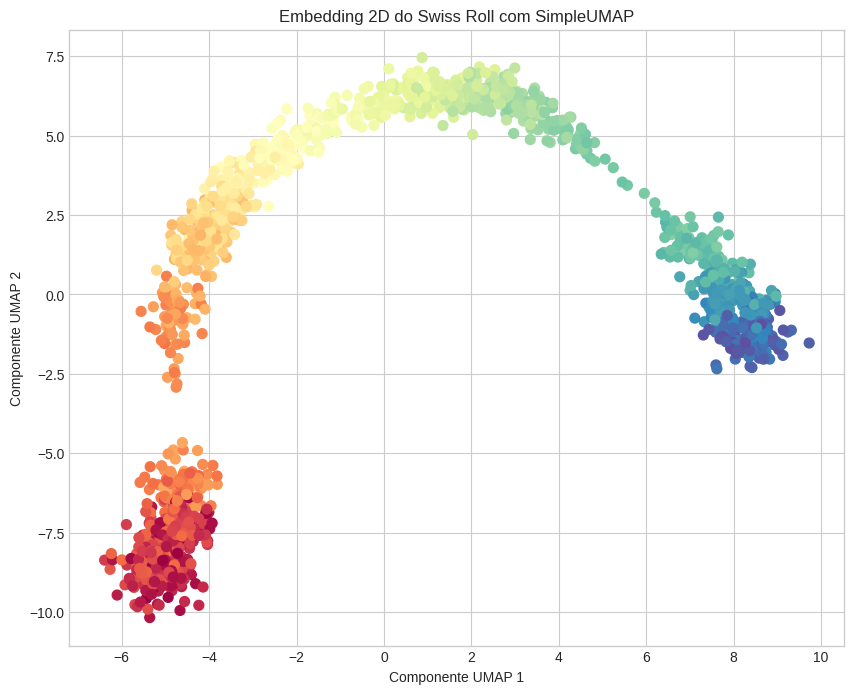

In [5]:
for K in [20, 30, 40]:
    # Instanciar e rodar o UMAP
    simple_umap = UMAP(n_neighbors=K, n_components=2, n_epochs=500, random_state=42)
    embedding = simple_umap.fit_transform(X) #shape1500,2 pois redução de dimensionalidade

    # Plotar o embedding 2D
    plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=color, cmap=plt.cm.Spectral, s=50)
    plt.title("Embedding 2D do Swiss Roll com SimpleUMAP")
    plt.xlabel("Componente UMAP 1")
    plt.ylabel("Componente UMAP 2")
    plt.show()

### Exercício 2

Visualize os dados do dataset MNIST utilizando UMAP.

In [1]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

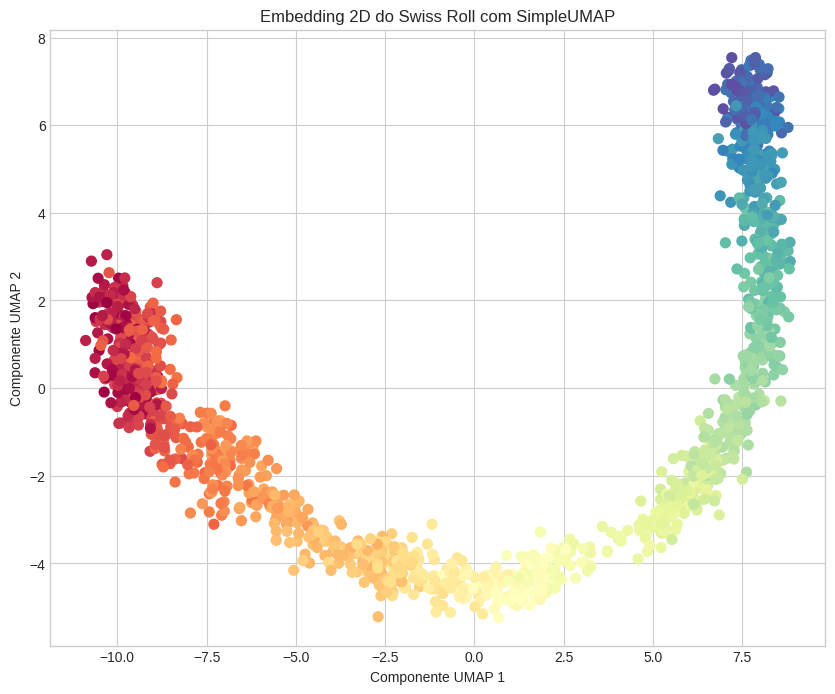

In [12]:

# Instanciar e rodar o UMAP
simple_umap = UMAP(n_neighbors=32, n_components=2, n_epochs=500, random_state=42)
embedding = simple_umap.fit_transform(X) #shape1500,2 pois redução de dimensionalidade

# Plotar o embedding 2D
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=color, cmap=plt.cm.Spectral, s=50)
plt.title("Embedding 2D do Swiss Roll com SimpleUMAP")
plt.xlabel("Componente UMAP 1")
plt.ylabel("Componente UMAP 2")
plt.show()